In [8]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

SEED = 12

In [9]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [10]:
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

In [11]:
# pizza.query('order_date >= "2015-11-01" & order_date < "2015-12-01"', inplace=True)

In [12]:
conteo = pizza.groupby(['order_date']).size().reset_index(name='n_orders')
conteo

,order_date,n_orders
0,2015-01-01,161
1,2015-01-02,160
2,2015-01-03,154
3,2015-01-04,106
4,2015-01-05,121
...,...,...
353,2015-12-27,87
354,2015-12-28,102
355,2015-12-29,77
356,2015-12-30,73


> Accion de gracias

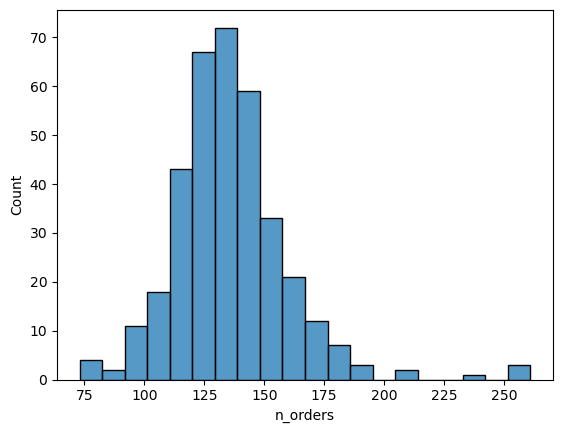

In [13]:
sns.histplot(conteo['n_orders'], bins=20);

In [14]:
obs = conteo['n_orders'].values

In [15]:
obs.var(), obs.mean()

(np.float64(577.2991167566555), np.float64(135.81005586592178))

## 1.
Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o más normales) y justificar la elección.

Buscamos grupos, empezando por dia tranquilo y día ajetreado (??)

In [16]:
obs.std()

np.float64(24.027049688978785)

In [38]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=obs.mean(), sigma=25, shape=k)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 59 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


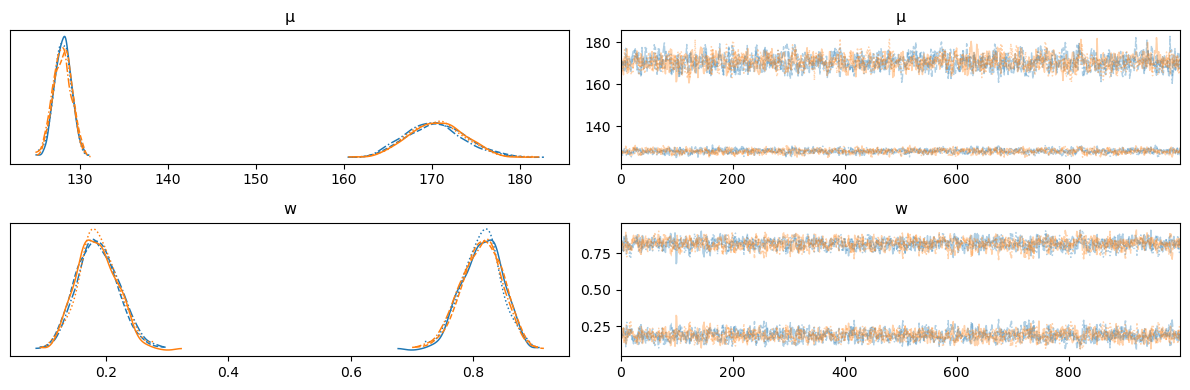

In [39]:
az.plot_trace(idata, var_names=['μ', 'w'])
plt.tight_layout();

## 2.
Analizar la identificabilidad del modelo y discutir posibles problemas de simetría entre componentes.

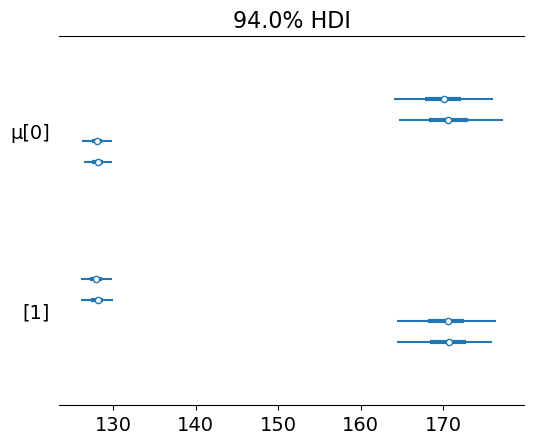

In [40]:
az.plot_forest(idata, var_names=['μ']);

In [41]:
μ_μ = np.quantile(obs, np.linspace(0.1, 0.9, k))
μ_μ

array([111., 161.])

In [43]:
k=2

with pm.Model() as poisson_mixture_model:
    μ = pm.Gamma('μ', mu=μ_μ, sigma=25, shape=k, transform=pm.distributions.transforms.ordered)
    w = pm.Dirichlet('w', a=np.ones(k))

    comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.


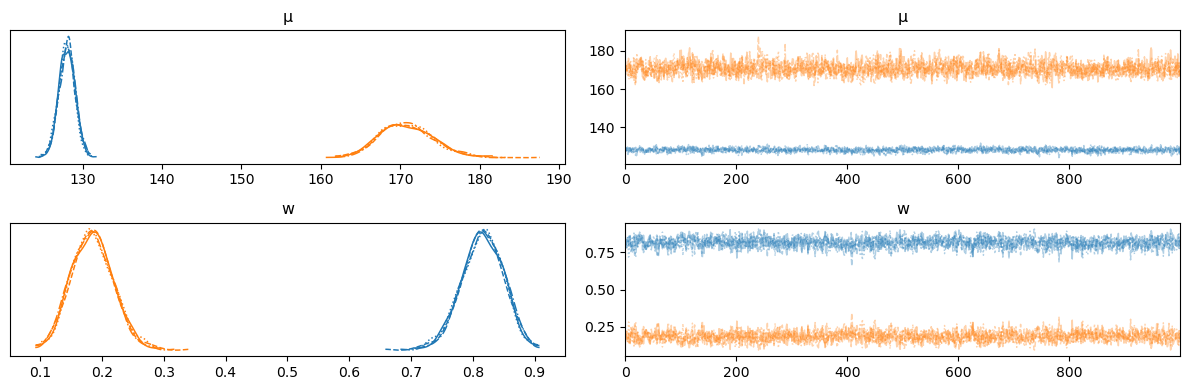

In [44]:
az.plot_trace(idata)
plt.tight_layout();

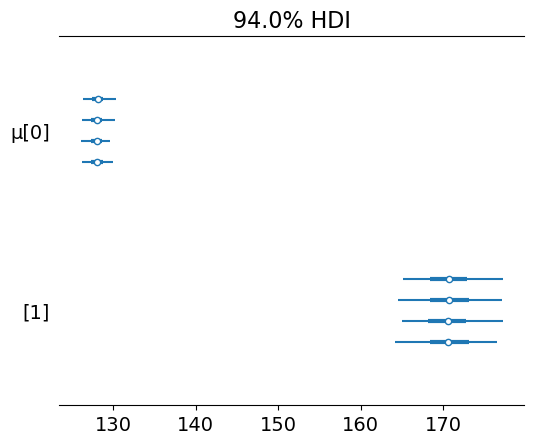

In [45]:
az.plot_forest(idata, var_names=['μ']);

In [46]:
az.summary(idata, kind="diagnostics")

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.022,0.014,2059.0,2367.0,1.0
μ[1],0.085,0.054,1556.0,2373.0,1.0
w[0],0.001,0.001,1527.0,2331.0,1.0
w[1],0.001,0.001,1527.0,2331.0,1.0


## 3.
Comparar distintos valores de K (número de componentes) y evaluar cuál describe mejor los datos.

In [47]:
Ks = [2, 3, 4, 5, 6]

idatas = []
modelos = []

for k in Ks:
    μ_μ = np.quantile(obs, np.linspace(0, 1, k))
    
    with pm.Model() as poisson_mixture_model:
        σ = pm.HalfNormal('σ', sigma=25)

        μ = pm.Gamma('μ', mu=μ_μ, sigma=σ, shape=k, transform=pm.distributions.transforms.ordered)
        w = pm.Dirichlet('w', a=np.ones(k))

        comps = [pm.Poisson.dist(mu=μ[i]) for i in range(k)]

        x = pm.Mixture('x', w=w, comp_dists=comps, observed=obs)

        idata = pm.sample(target_accept=0.95, idata_kwargs={"log_likelihood": True}, random_seed=SEED)

        idatas.append(idata)
        modelos.append(poisson_mixture_model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 76 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 79 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, μ, w]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 106 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 155 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [σ, μ, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 223 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


In [48]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
df_comp

c:\Users\nazar\anaconda3\envs\ei2\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
k=6,0,-1615.217515,9.610211,0.000000,9.472115e-01,18.581390,0.000000,False,log
k=5,1,-1615.786615,10.149622,0.569100,5.507691e-15,18.640966,0.395704,False,log
k=4,2,-1621.362125,10.959952,6.144609,6.502565e-15,19.869331,3.283965,False,log
k=3,3,-1660.972964,17.423897,45.755448,5.981258e-15,27.897124,13.900544,True,log
k=2,4,-1732.007682,17.665687,116.790167,5.278848e-02,48.906555,36.110629,False,log


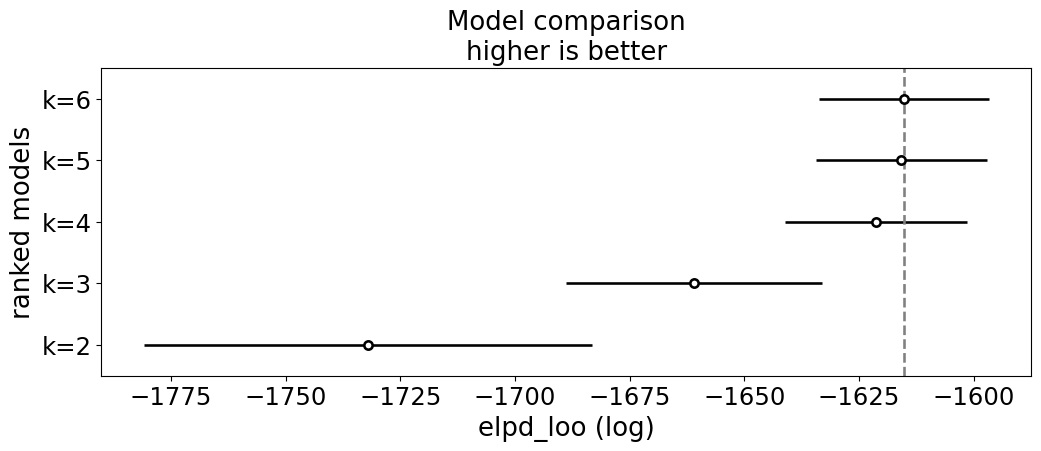

In [49]:
az.plot_compare(df_comp, figsize=(12, 4));

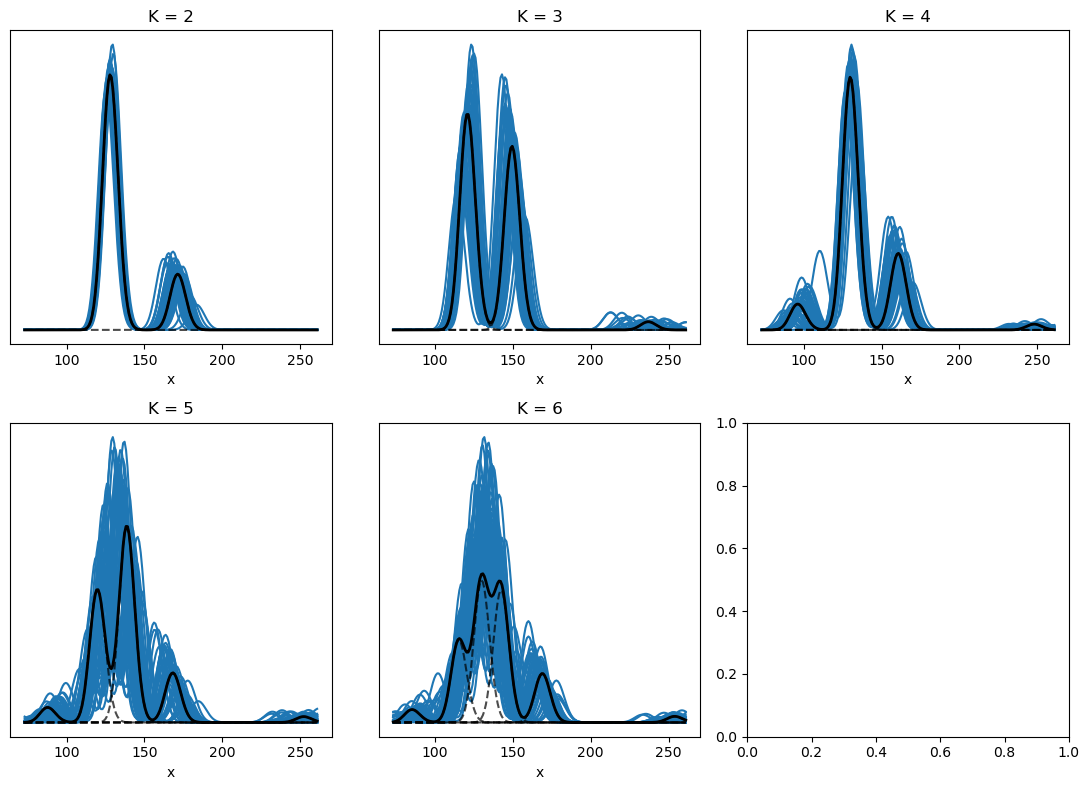

In [50]:
fig, ax = plt.subplots(2, 3, figsize=(11, 8))

ax = np.ravel(ax)
x = np.linspace(obs.min(), obs.max(), 200)
for idx, idata_x in enumerate(idatas):
    posterior_x = idata_x.posterior.stack(samples=("chain", "draw"))
    x_ = np.array([x] * Ks[idx]).T

    for i_ in np.random.randint(0, posterior_x.samples.size, size=50):
        dist = pz.Gamma(mu=posterior_x['μ'][:,i_], sigma=5)
        ax[idx].plot(x, np.sum(dist.pdf(x_) *  posterior_x['w'][:,i_].values, 1), 'C0')
 
    p_y = posterior_x['w'].mean("samples")
    dist = pz.Gamma(mu=posterior_x['μ'].mean("samples"), sigma=5)
    ax[idx].plot(x, np.sum(dist.pdf(x_) * p_y.values, 1), 'k', lw=2)
    ax[idx].plot(x, dist.pdf(x_) * p_y.values, 'k--', alpha=0.7)
         
    ax[idx].set_title('K = {}'.format(Ks[idx]))
    ax[idx].set_yticks([])
    ax[idx].set_xlabel('x')

plt.tight_layout();

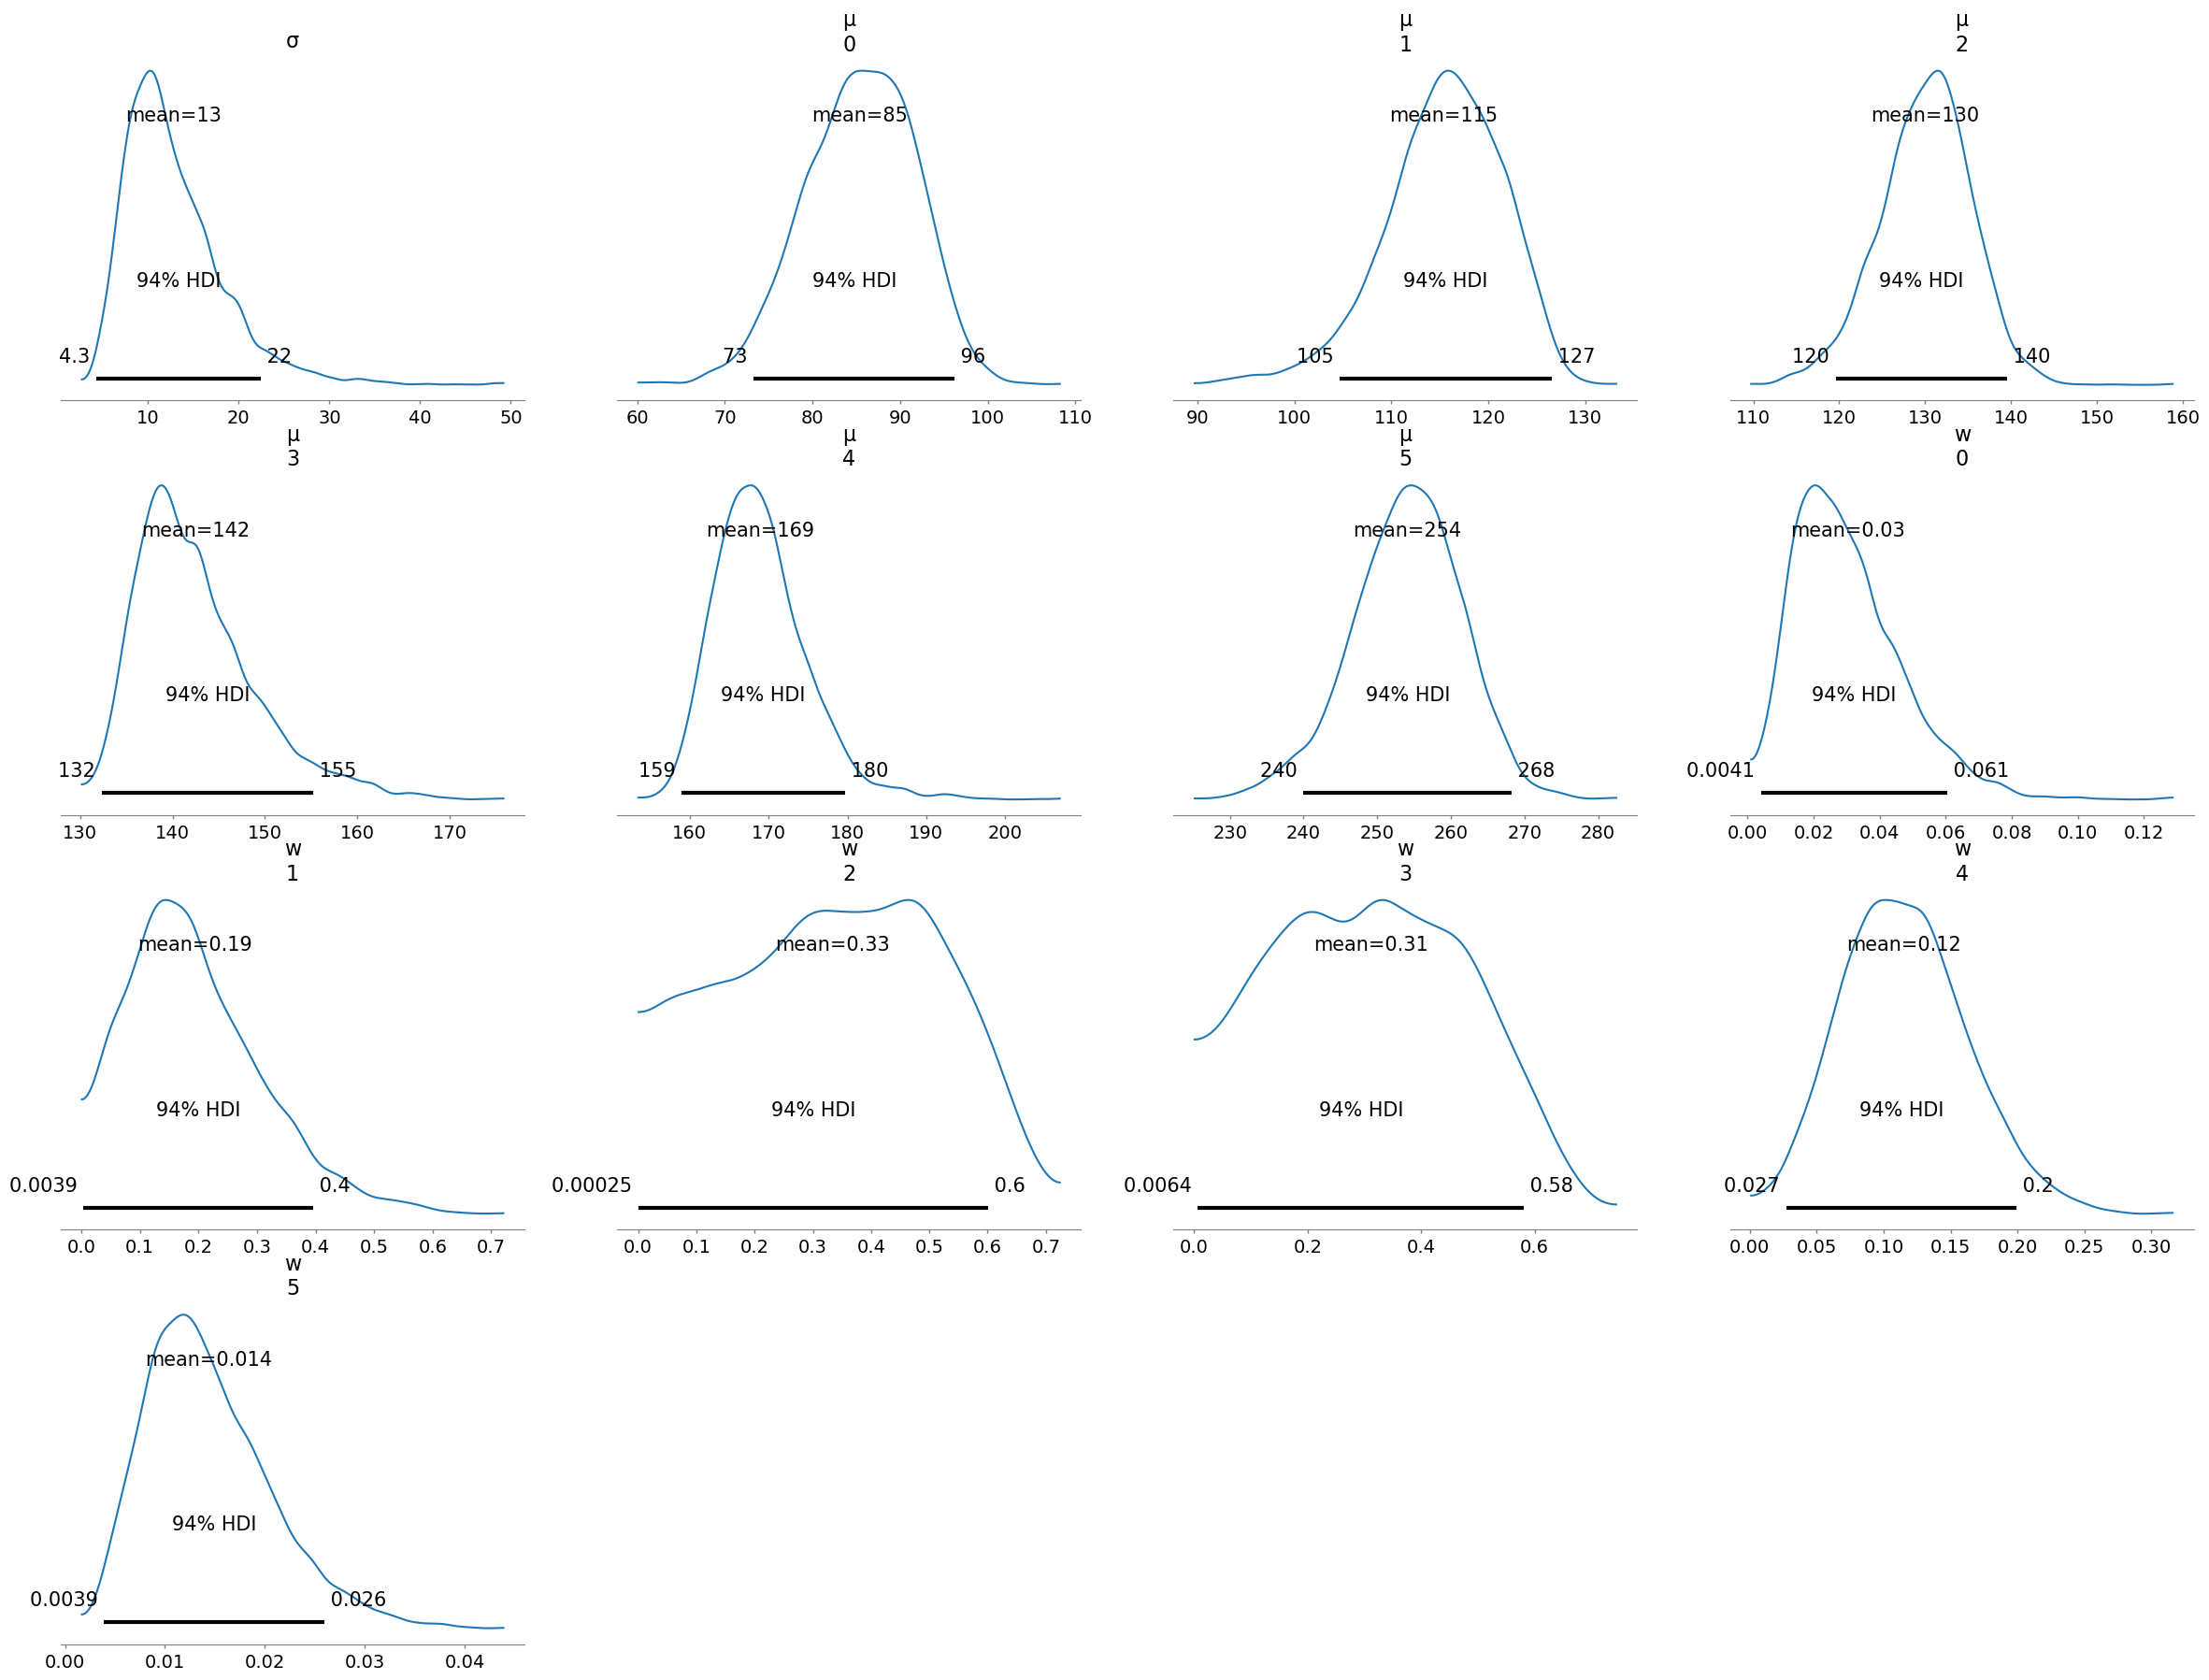

In [54]:
az.plot_posterior(idatas[4]);

1. 85 (73 - 96 HDI94% ???????????) ventas el 3 (HDI ???????)% de los días
2. 115 ventas el 19% de los días
3. 130 ventas el 33% de los días
4. 142 ventas el 31% de los días
5. 169 ventas el 12% de los días
6. 254 ventas el 1.4% de los días

In [52]:
for i, k in enumerate(Ks):
    modelo = modelos[i]
    idata = idatas[i]
    pm.sample_posterior_predictive(idata, model=modelo, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

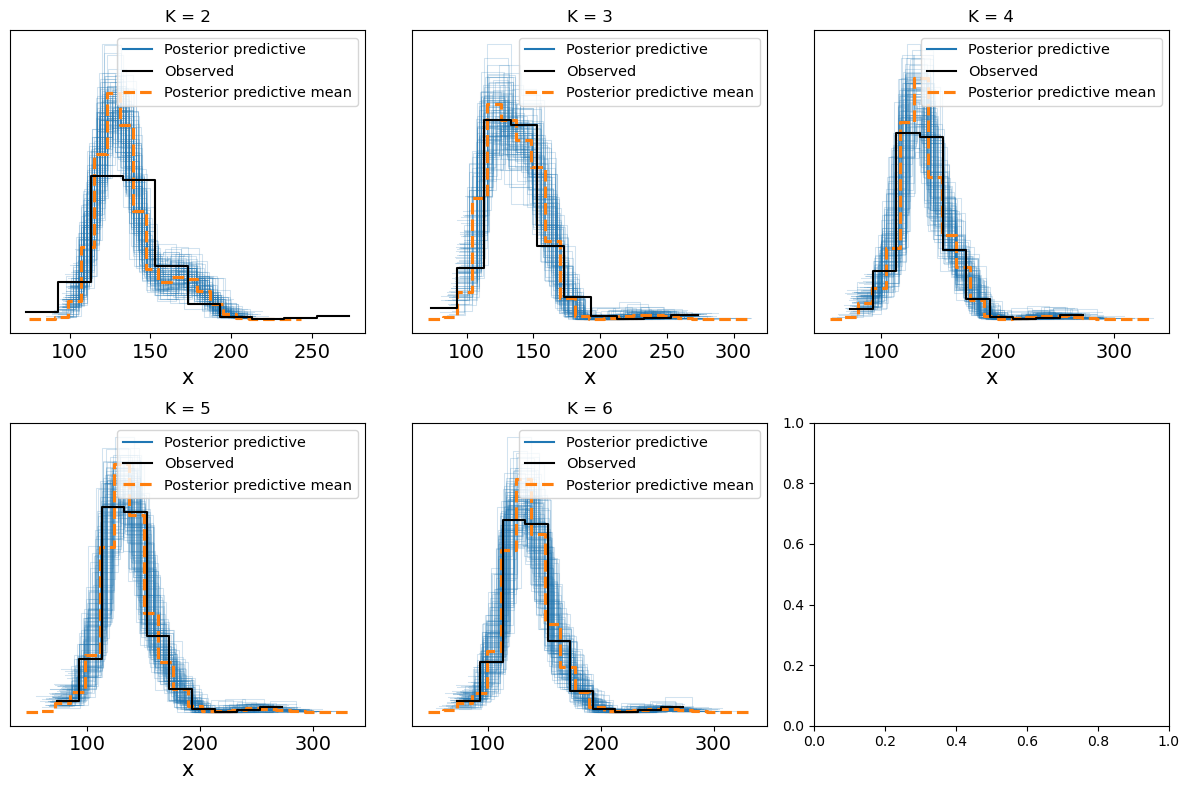

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = np.ravel(axes)
for i, idata in enumerate(idatas):
    az.plot_ppc(idata, num_pp_samples=100, ax=axes[i])
    axes[i].set_title('K = {}'.format(Ks[i]))

plt.tight_layout();

El mejor modelo identifica 6 grupos, ¿cuales podrían ser?:

1. dia tranquilo (capaz lunes a miercoles)
2. dia demandante (capaz jueves y viernes)
3. fin de semana
4. día festivo tranquilo
5. día festivo demandante
6. día festivo muy demandante

esto es demasiado especifico (el día muy demandante es prbable que sea uno solo, accion de gracias)

entonces usamos k=4, porque es mas general y esta dentro del error estandar del modelo con 6 componentes (> PONER NUMEROS)

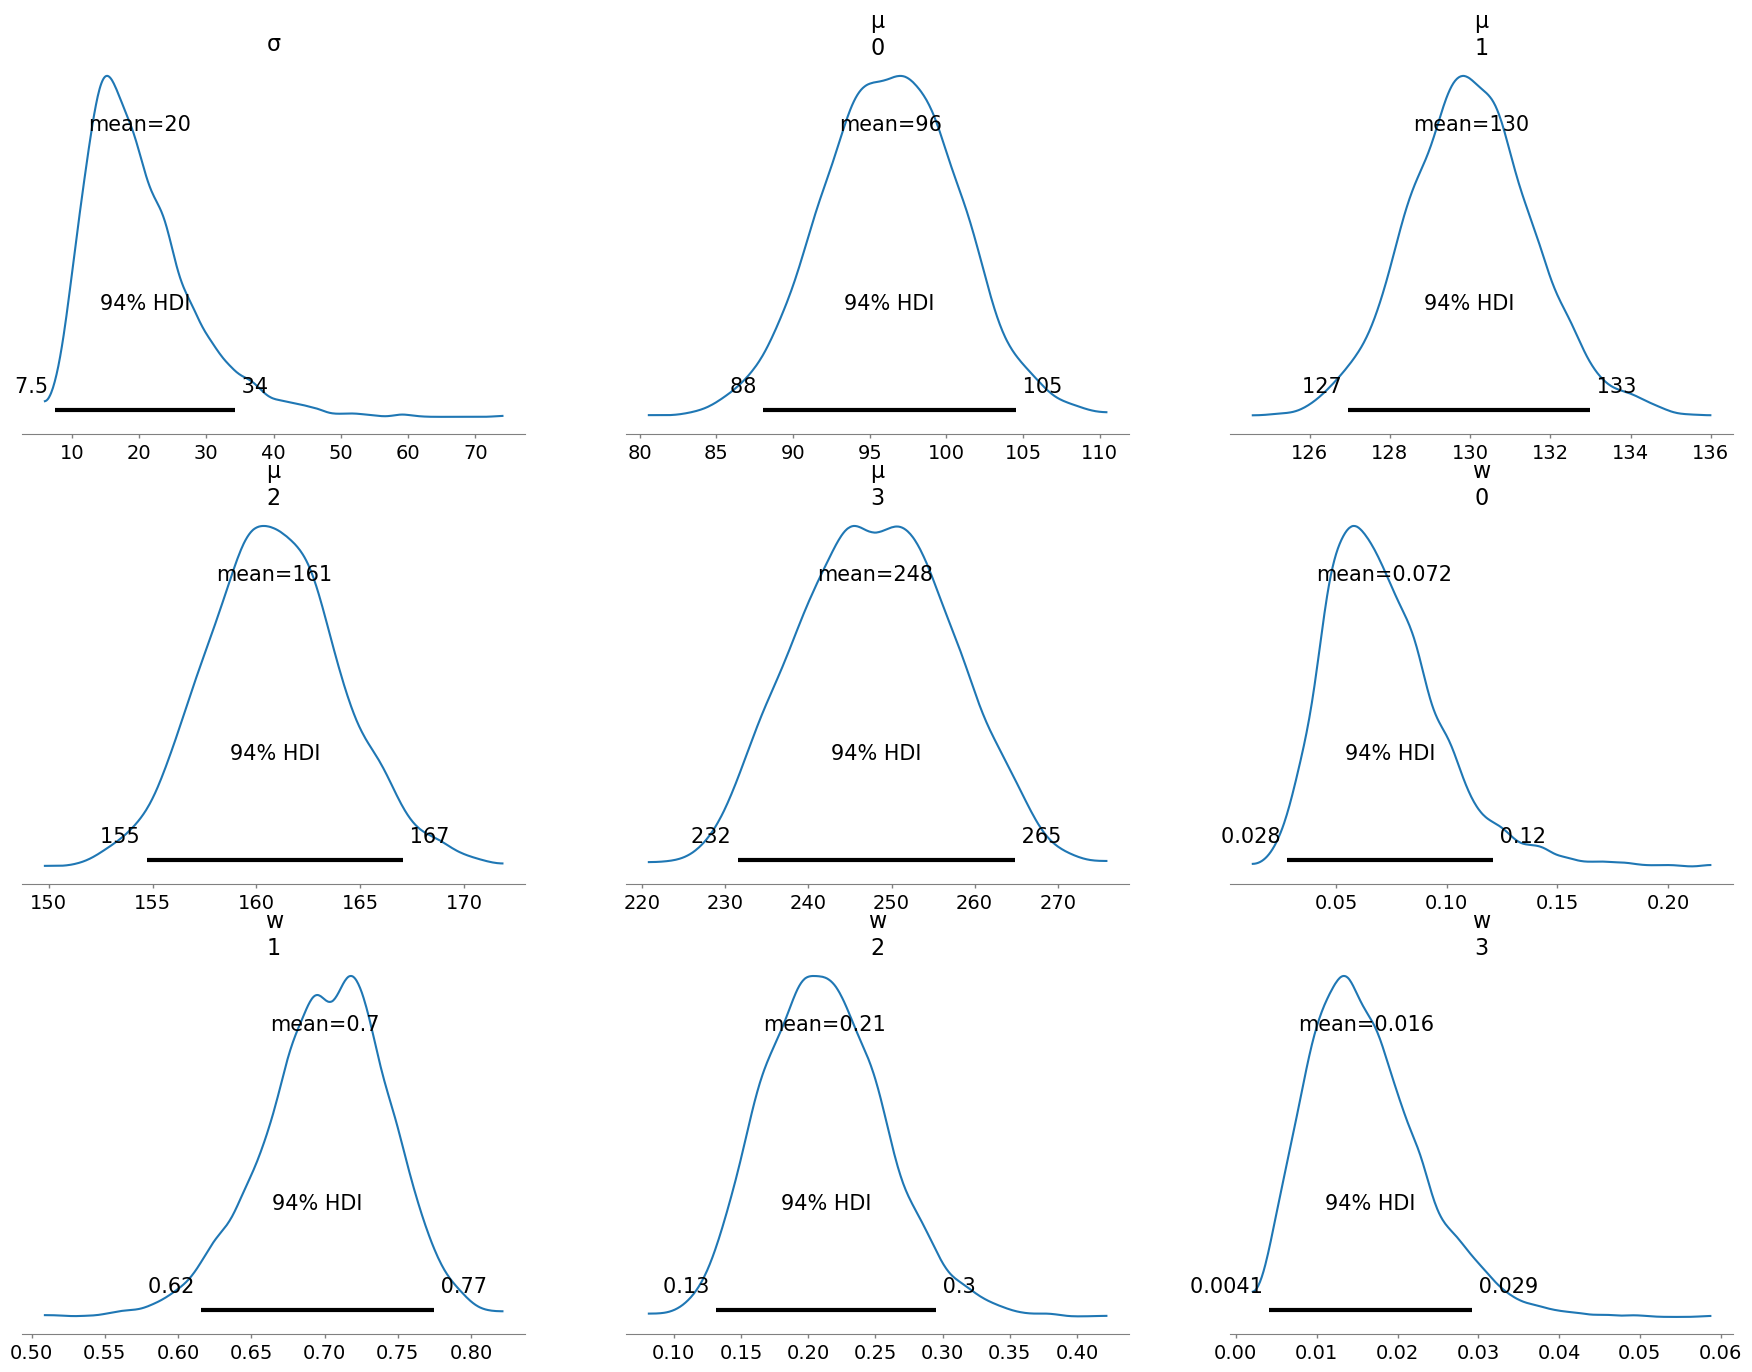

In [57]:
az.plot_posterior(idatas[2]);

1. Dia lento: 96 ventas el 7% de los días
2. Dia normal: 130 ventas el 70% de los días
3. Dia ajetreado: 161 ventas el 21% de los días
4. Día inusual: 248 ventas el 1.6% de los días

Vemos los días inusuales

In [63]:
conteo[conteo['n_orders']> 230]

,order_date,n_orders
184,2015-07-04,233
283,2015-10-15,258
323,2015-11-26,261
324,2015-11-27,259


Son festividades:  
Dia de la independencia  
Dia de la herencia latina  
Accion de gracias

Vemos otros días

In [65]:
conteo['day_of_week'] = conteo['order_date'].dt.day_name()
conteo

,order_date,n_orders,day_of_week
0,2015-01-01,161,Thursday
1,2015-01-02,160,Friday
2,2015-01-03,154,Saturday
3,2015-01-04,106,Sunday
4,2015-01-05,121,Monday
...,...,...,...
353,2015-12-27,87,Sunday
354,2015-12-28,102,Monday
355,2015-12-29,77,Tuesday
356,2015-12-30,73,Wednesday


In [67]:
conteo.query('n_orders >=155 and n_orders <= 167').day_of_week.value_counts()

day_of_week
Friday       15
Saturday      8
Thursday      5
Wednesday     3
Tuesday       3
Monday        1
Name: count, dtype: int64

Son generalmente viernes y sabados tranquilos.

Vemos días lentos

In [68]:
conteo.query('n_orders <= 105').day_of_week.value_counts()

day_of_week
Sunday       15
Tuesday       3
Monday        2
Wednesday     2
Saturday      1
Name: count, dtype: int64

Son domingos y dias muy lentos